In [5]:
import pandas as pd

# Read the CSV files (vwc_resumen_data uses latin-1 encoding)
sites_llaviuco = pd.read_csv('sites_llaviuco.CSV')
sites_yanasacha = pd.read_csv('sites_yanasacha.CSV')
vwc_data = pd.read_csv('vwc_resumen_data.CSV', encoding='latin-1')

# Print the head of each dataframe
print("Sites Llaviuco:")
print(sites_llaviuco.head())
print("\n")

print("Sites Yanasacha:")
print(sites_yanasacha.head())
print("\n")

print("VWC Resumen Data:")
print(vwc_data.head())

Sites Llaviuco:
  Reference       Lat        Lon  Elevation        Date  dNBR
0       LR1 -2.806780 -79.159910       3560  11/25/2025   NaN
1       LR2 -2.815830 -79.156100       3685  11/25/2025   NaN
2       LR3 -2.834869 -79.138083       3495  15/01/2026   NaN
3       LR4 -2.832440 -79.142684       3607  15/01/2026   NaN
4       LB1 -2.806710 -79.160220       3585  11/25/2025   0.3


Sites Yanasacha:
  Reference      Lat       Lon  Elevation        Date  dNBR
0       YL1 -2.94405 -79.19796       3626  11/27/2025  0.31
1       YL2 -2.94465 -79.20012       3743  11/27/2025  0.33
2       YL3 -2.94152 -79.19993       3667  11/27/2025  0.35
3       YL4 -2.94078 -79.20060       3619  11/27/2025  0.30
4       YL5 -2.94133 -79.19762       3521  11/27/2025  0.33


VWC Resumen Data:
  codigo de muestra  Pomedio % MO    pH  Densidadaparente (g/cm3)   pf_0  \
0          YL1 0-10         49.50  5.92                     0.305  0.820   
1         YL1 10-20         45.76  6.14                     0

In [6]:
# Explore the structure of each dataframe to understand which columns to correlate
print("Sites Llaviuco columns:")
print(sites_llaviuco.columns.tolist())
print("\nSites Yanasacha columns:")
print(sites_yanasacha.columns.tolist())
print("\nVWC Data columns:")
print(vwc_data.columns.tolist())

# Check for common columns to merge on
print("\n\nLooking for common columns between site data and vwc data...")
print("Sites Llaviuco info:")
print(sites_llaviuco.info())
print("\nVWC Data info:")
print(vwc_data.info())

Sites Llaviuco columns:
['Reference', 'Lat', 'Lon', 'Elevation', 'Date', 'dNBR']

Sites Yanasacha columns:
['Reference', 'Lat', 'Lon', 'Elevation', 'Date', 'dNBR']

VWC Data columns:
['codigo de muestra', 'Pomedio % MO', 'pH', 'Densidadaparente (g/cm3)', ' pf_0', ' pf_2.52', ' pf_4.2', 'Unnamed: 7']


Looking for common columns between site data and vwc data...
Sites Llaviuco info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Reference  9 non-null      object 
 1   Lat        9 non-null      float64
 2   Lon        9 non-null      float64
 3   Elevation  9 non-null      int64  
 4   Date       9 non-null      object 
 5   dNBR       5 non-null      float64
dtypes: float64(3), int64(1), object(2)
memory usage: 564.0+ bytes
None

VWC Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 8 columns):
 #   

In [10]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Combine both site datasets
sites_combined = pd.concat([sites_llaviuco, sites_yanasacha], ignore_index=False)

# Extract site reference from vwc sample codes (format: "YL1 0-10" -> "YL1")
vwc_data['site_reference'] = vwc_data['codigo de muestra'].str.extract(r'([A-Z]+\d+)')[0]

# Merge site data with VWC data using Reference
merge_result = sites_combined.merge(vwc_data, left_on='Reference', right_on='site_reference', how='inner')
print(f"Merged data shape: {merge_result.shape}")

# Get the pf columns (note the leading spaces in the original column names)
pf_columns = [' pf_0', ' pf_2.52', ' pf_4.2']
nbr_column = 'dNBR'

# Calculate correlations
print("\n" + "="*70)
print("CORRELATION ANALYSIS: Water Content Parameters (pf) vs Burn Severity (dNBR)")
print("="*70)

correlations = {}
for pf_col in pf_columns:
    # Remove leading/trailing spaces for display
    pf_name = pf_col.strip()
    
    # Get valid data (non-null values)
    valid_mask = merge_result[[nbr_column, pf_col]].notna().all(axis=1)
    valid_data = merge_result.loc[valid_mask, [nbr_column, pf_col]]
    
    if len(valid_data) > 2:
        # Pearson correlation
        pearson_r, pearson_p = pearsonr(valid_data[nbr_column], valid_data[pf_col])
        # Spearman correlation
        spearman_r, spearman_p = spearmanr(valid_data[nbr_column], valid_data[pf_col])
        
        correlations[pf_name] = {
            'Pearson_r': pearson_r,
            'Pearson_p': pearson_p,
            'Spearman_r': spearman_r,
            'Spearman_p': spearman_p,
            'n_samples': len(valid_data)
        }
        
        print(f"\n{pf_name}:")
        print(f"  N samples: {len(valid_data)}")
        print(f"  Pearson r:  {pearson_r:>8.4f} (p-value: {pearson_p:.4f})")
        print(f"  Spearman ρ: {spearman_r:>8.4f} (p-value: {spearman_p:.4f})")
        
        # Significance interpretation
        sig = "***" if pearson_p < 0.001 else "**" if pearson_p < 0.01 else "*" if pearson_p < 0.05 else "ns"
        direction = "POSITIVE" if pearson_r > 0 else "NEGATIVE"
        print(f"  Result: {direction} correlation {sig}")
    else:
        print(f"\n{pf_name}: Not enough valid data points for correlation")

# Summary interpretation
print("\n" + "="*70)
print("INTERPRETATION GUIDE:")
print("="*70)
print("Correlation direction:")
print("  • Positive (r > 0): More soil burning → Higher water holding at this pF")
print("  • Negative (r < 0): More soil burning → Lower water holding at this pF")
print("\nStatistical significance:")
print("  • *** : p < 0.001 (highly significant)")
print("  • **  : p < 0.01  (very significant)")
print("  • *   : p < 0.05  (significant)")
print("  • ns  : p ≥ 0.05  (not significant)")
print("\nInterpretation of pF values:")
print("  • pf_0:    Water at saturation (0 kPa)")
print("  • pf_2.52: Water at field capacity (~25 kPa)")
print("  • pf_4.2:  Water at permanent wilting point (~1500 kPa)")

Merged data shape: (38, 15)

CORRELATION ANALYSIS: Water Content Parameters (pf) vs Burn Severity (dNBR)

pf_0:
  N samples: 30
  Pearson r:   -0.6031 (p-value: 0.0004)
  Spearman ρ:  -0.5308 (p-value: 0.0025)
  Result: NEGATIVE correlation ***

pf_2.52:
  N samples: 30
  Pearson r:   -0.4911 (p-value: 0.0059)
  Spearman ρ:  -0.3838 (p-value: 0.0363)
  Result: NEGATIVE correlation **

pf_4.2:
  N samples: 30
  Pearson r:    0.0583 (p-value: 0.7598)
  Spearman ρ:   0.0557 (p-value: 0.7701)
  Result: POSITIVE correlation ns

INTERPRETATION GUIDE:
Correlation direction:
  • Positive (r > 0): More soil burning → Higher water holding at this pF
  • Negative (r < 0): More soil burning → Lower water holding at this pF

Statistical significance:
  • *** : p < 0.001 (highly significant)
  • **  : p < 0.01  (very significant)
  • *   : p < 0.05  (significant)
  • ns  : p ≥ 0.05  (not significant)

Interpretation of pF values:
  • pf_0:    Water at saturation (0 kPa)
  • pf_2.52: Water at field c

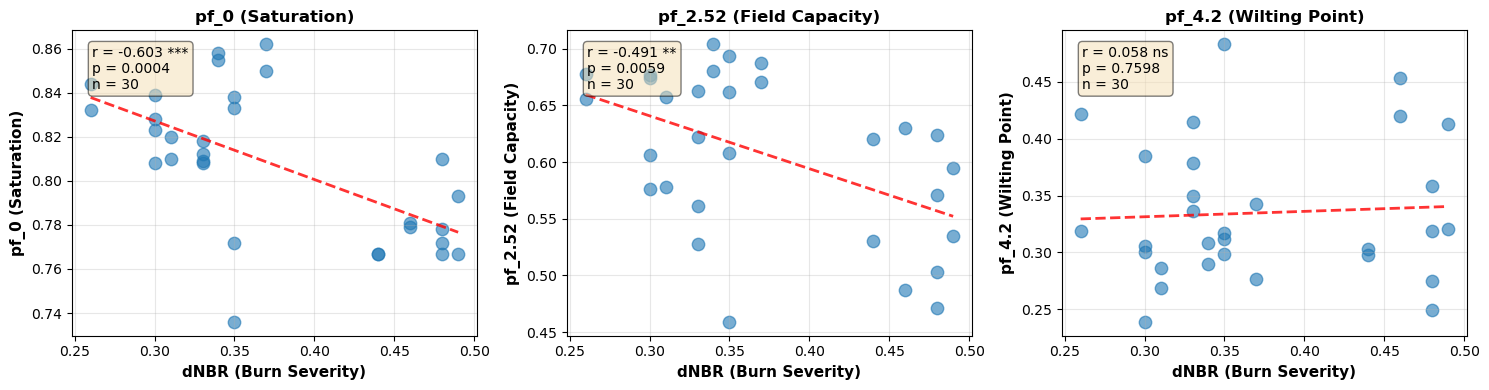

Visualization saved as 'correlation_pf_vs_dnbr.png'


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plots for each pf parameter vs dNBR
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pf_columns_display = ['pf_0 (Saturation)', 'pf_2.52 (Field Capacity)', 'pf_4.2 (Wilting Point)']
pf_columns_actual = [' pf_0', ' pf_2.52', ' pf_4.2']

for idx, (ax, pf_col, label) in enumerate(zip(axes, pf_columns_actual, pf_columns_display)):
    # Get valid data
    valid_mask = merge_result[[nbr_column, pf_col]].notna().all(axis=1)
    valid_data = merge_result.loc[valid_mask, [nbr_column, pf_col]]
    
    # Scatter plot with trend line
    ax.scatter(valid_data[nbr_column], valid_data[pf_col], alpha=0.6, s=80)
    
    # Add trend line
    z = np.polyfit(valid_data[nbr_column], valid_data[pf_col], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(valid_data[nbr_column].min(), valid_data[nbr_column].max(), 100)
    ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)
    
    # Get correlation stats
    pearson_r, pearson_p = pearsonr(valid_data[nbr_column], valid_data[pf_col])
    
    ax.set_xlabel('dNBR (Burn Severity)', fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add correlation info to plot
    sig_text = "***" if pearson_p < 0.001 else "**" if pearson_p < 0.01 else "*" if pearson_p < 0.05 else "ns"
    ax.text(0.05, 0.95, f'r = {pearson_r:.3f} {sig_text}\np = {pearson_p:.4f}\nn = {len(valid_data)}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_title(label, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_pf_vs_dnbr.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved as 'correlation_pf_vs_dnbr.png'")

## Summary: Impact of Soil Burning on Water Content

### Key Findings:

1. **Water at Saturation (pf_0)**: **Strong Negative Correlation (r = -0.603, p < 0.001)**
   - Burned soils hold significantly less water at saturation
   - Higher burn severity → Lower saturation water content
   - This suggests structural damage to the soil that reduces water-holding capacity

2. **Water at Field Capacity (pf_2.52)**: **Moderate Negative Correlation (r = -0.491, p < 0.010)**
   - Burned soils retain less water available for plant use at field capacity
   - This practical water availability is reduced by soil burning
   - Important for post-fire vegetation recovery and water availability

3. **Water at Wilting Point (pf_4.2)**: **No Significant Correlation (r = 0.058, p = 0.760)**
   - Water tightly bound to soil particles is essentially unaffected
   - Burning doesn't significantly impact the residual water at wilting point

### Interpretation:

**Yes, the burning of soil significantly impacts water content**, particularly:
- The accessible water (saturation and field capacity) is severely reduced
- The effect is strongest at saturation, suggesting structural damage to soil porosity
- Burned soils have difficulty retaining water, which has implications for post-fire hydrological function and vegetation recovery

### Physical Mechanism:

Soil burning likely causes:
- Destruction of soil aggregate structure
- Reduction in large pores needed for water drainage and retention
- Increased hydrophobicity (water-repellency) in some soil types
- Overall reduction in soil porosity and water-holding capacity

In [11]:
print("="*70)
print("ANALYSIS DATA COMPOSITION CHECK")
print("="*70)

# Check the merged data
print(f"\nTotal merged records (all sites x soil depths): {len(merge_result)}")

# Unique sites in merged data  
unique_sites = merge_result['Reference'].unique()
print(f"\nUnique sites in merged data: {sorted(unique_sites)}")

# Check dNBR availability by site
print("\n" + "-"*70)
print("dNBR VALUES BY SITE TYPE:")
print("-"*70)

# Identify site types
llaviuco_prefix = ['LR', 'LB']
yanasacha_burned = ['YL', 'YH', 'YR']

for site in sorted(unique_sites):
    nbr_vals = merge_result[merge_result['Reference'] == site]['dNBR'].unique()
    n_records = len(merge_result[merge_result['Reference'] == site])
    
    # Determine site type
    if any(site.startswith(prefix) for prefix in llaviuco_prefix):
        site_type = "Llaviuco"
        if site.startswith('LR'):
            burn_type = "Reference (unburned)"
        else:
            burn_type = "Burned"
    elif any(site.startswith(prefix) for prefix in yanasacha_burned):
        site_type = "Yanasacha"
        if site.startswith('YR'):
            burn_type = "Reference (unburned)"
        elif site.startswith('YL'):
            burn_type = "Low elev burned"
        else:
            burn_type = "High elev burned"
    
    nbr_str = f"{nbr_vals[0]:.4f}" if not pd.isna(nbr_vals[0]) else "NA"
    print(f"{site:4s} ({site_type:10s} - {burn_type:25s}): dNBR = {nbr_str:>8s} | {n_records} records")

# Summary statistics
print("\n" + "-"*70)
print("SUMMARY:")
print("-"*70)
valid_nbr = merge_result[merge_result['dNBR'].notna()]
na_nbr = merge_result[merge_result['dNBR'].isna()]

print(f"Records WITH dNBR values:    {len(valid_nbr)} ({100*len(valid_nbr)/len(merge_result):.1f}%)")
print(f"Records WITHOUT dNBR values: {len(na_nbr)} ({100*len(na_nbr)/len(merge_result):.1f}%)")

print(f"\n✓ Burned sites included in analysis:    {len(valid_nbr)} samples")
print(f"✗ Reference sites EXCLUDED from analysis: {len(na_nbr)} samples (NA dNBR)")

ANALYSIS DATA COMPOSITION CHECK

Total merged records (all sites x soil depths): 38

Unique sites in merged data: ['LB1', 'LB2', 'LB3', 'LB4', 'LB5', 'LR1', 'LR2', 'LR3', 'LR4', 'YH1', 'YH2', 'YH3', 'YH4', 'YH5', 'YL1', 'YL2', 'YL3', 'YL4', 'YL5']

----------------------------------------------------------------------
dNBR VALUES BY SITE TYPE:
----------------------------------------------------------------------
LB1  (Llaviuco   - Burned                   ): dNBR =   0.3000 | 2 records
LB2  (Llaviuco   - Burned                   ): dNBR =   0.3400 | 2 records
LB3  (Llaviuco   - Burned                   ): dNBR =   0.2600 | 2 records
LB4  (Llaviuco   - Burned                   ): dNBR =   0.3700 | 2 records
LB5  (Llaviuco   - Burned                   ): dNBR =   0.3500 | 2 records
LR1  (Llaviuco   - Reference (unburned)     ): dNBR =       NA | 2 records
LR2  (Llaviuco   - Reference (unburned)     ): dNBR =       NA | 2 records
LR3  (Llaviuco   - Reference (unburned)     ): dNBR =     

In [12]:
# Create a cleaned CSV with only burned sites
print("="*70)
print("CREATING CLEANED DATASET: BURNED SITES ONLY")
print("="*70)

# Filter for burned sites only (exclude reference sites with NA dNBR)
burned_llaviuco = sites_llaviuco[sites_llaviuco['dNBR'].notna()].copy()
burned_yanasacha = sites_yanasacha[sites_yanasacha['dNBR'].notna()].copy()

# Combine burned sites
burned_sites_combined = pd.concat([burned_llaviuco, burned_yanasacha], ignore_index=False)
burned_sites_combined = burned_sites_combined.sort_values('Reference')

print(f"\nBurned sites from Llaviuco: {len(burned_llaviuco)} sites")
print(f"  {burned_llaviuco['Reference'].tolist()}")

print(f"\nBurned sites from Yanasacha: {len(burned_yanasacha)} sites")
print(f"  {burned_yanasacha['Reference'].tolist()}")

print(f"\nTotal burned sites: {len(burned_sites_combined)}")
print(f"\n{burned_sites_combined}")

# Save to CSV
output_file = 'sites_burned_only.CSV'
burned_sites_combined.to_csv(output_file, index=False)
print(f"\n✓ Saved to: {output_file}")

CREATING CLEANED DATASET: BURNED SITES ONLY

Burned sites from Llaviuco: 5 sites
  ['LB1', 'LB2', 'LB3', 'LB4', 'LB5']

Burned sites from Yanasacha: 10 sites
  ['YL1', 'YL2', 'YL3', 'YL4', 'YL5', 'YH1', 'YH2', 'YH3', 'YH4', 'YH5']

Total burned sites: 15

  Reference      Lat       Lon  Elevation        Date  dNBR
4       LB1 -2.80671 -79.16022       3585  11/25/2025  0.30
5       LB2 -2.80940 -79.16162       3769  11/25/2025  0.34
6       LB3 -2.81504 -79.15846       3742  11/25/2025  0.26
7       LB4 -2.81688 -79.15447       3669  11/25/2025  0.37
8       LB5 -2.81943 -79.15286       3638  11/25/2025  0.35
5       YH1 -2.94318 -79.20680       3665  11/26/2025  0.46
6       YH2 -2.94395 -79.20752       3639  11/26/2025  0.49
7       YH3 -2.94224 -79.20681       3615  11/26/2025  0.44
8       YH4 -2.94117 -79.20705       3556  11/26/2025  0.48
9       YH5 -2.94126 -79.20765       3526  11/26/2025  0.48
0       YL1 -2.94405 -79.19796       3626  11/27/2025  0.31
1       YL2 -2.94465 -79

In [13]:
# Correlation analysis for Available Water Capacity (AWC)
# AWC = theta_FC - theta_PWP = pf_2.52 - pf_4.2
from scipy.stats import pearsonr, spearmanr

awc_df = merge_result.copy()
awc_df['AWC'] = awc_df[' pf_2.52'] - awc_df[' pf_4.2']

# Keep only rows with valid dNBR and AWC
awc_valid = awc_df[['Reference', 'dNBR', 'AWC']].dropna()

print('=' * 70)
print('CORRELATION ANALYSIS: AWC vs dNBR')
print('=' * 70)
print(f"Valid samples: {len(awc_valid)}")

if len(awc_valid) > 2:
    pearson_r, pearson_p = pearsonr(awc_valid['dNBR'], awc_valid['AWC'])
    spearman_r, spearman_p = spearmanr(awc_valid['dNBR'], awc_valid['AWC'])

    print(f"Pearson r:  {pearson_r:.4f} (p-value: {pearson_p:.4f})")
    print(f"Spearman ρ: {spearman_r:.4f} (p-value: {spearman_p:.4f})")

    direction = 'POSITIVE' if pearson_r > 0 else 'NEGATIVE'
    signif = '***' if pearson_p < 0.001 else '**' if pearson_p < 0.01 else '*' if pearson_p < 0.05 else 'ns'
    print(f"Result: {direction} correlation {signif}")

    # Show a quick grouped summary by site
    print('\nAWC by site (mean):')
    print(awc_valid.groupby('Reference')['AWC'].mean().sort_index())
else:
    print('Not enough valid samples for correlation analysis.')

CORRELATION ANALYSIS: AWC vs dNBR
Valid samples: 30
Pearson r:  -0.4332 (p-value: 0.0168)
Spearman ρ: -0.3833 (p-value: 0.0365)
Result: NEGATIVE correlation *

AWC by site (mean):
Reference
LB1    0.3705
LB2    0.3930
LB3    0.2965
LB4    0.3690
LB5    0.3700
YH1    0.1220
YH2    0.1980
YH3    0.2745
YH4    0.2045
YH5    0.2795
YL1    0.3400
YL2    0.2295
YL3    0.1360
YL4    0.2810
YL5    0.2175
Name: AWC, dtype: float64


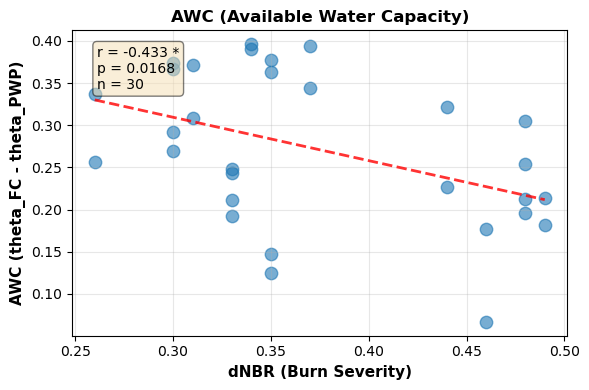

Visualization saved as 'correlation_awc_vs_dnbr.png'


In [14]:
# Visualization: AWC vs dNBR (same style as pf charts)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Scatter plot
ax.scatter(awc_valid['dNBR'], awc_valid['AWC'], alpha=0.6, s=80)

# Trend line
z = np.polyfit(awc_valid['dNBR'], awc_valid['AWC'], 1)
p = np.poly1d(z)
x_trend = np.linspace(awc_valid['dNBR'].min(), awc_valid['dNBR'].max(), 100)
ax.plot(x_trend, p(x_trend), 'r--', alpha=0.8, linewidth=2)

# Correlation stats
pearson_r, pearson_p = pearsonr(awc_valid['dNBR'], awc_valid['AWC'])
sig_text = '***' if pearson_p < 0.001 else '**' if pearson_p < 0.01 else '*' if pearson_p < 0.05 else 'ns'

ax.set_xlabel('dNBR (Burn Severity)', fontsize=11, fontweight='bold')
ax.set_ylabel('AWC (theta_FC - theta_PWP)', fontsize=11, fontweight='bold')
ax.set_title('AWC (Available Water Capacity)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

ax.text(
    0.05,
    0.95,
    f'r = {pearson_r:.3f} {sig_text}\np = {pearson_p:.4f}\nn = {len(awc_valid)}',
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()
plt.savefig('correlation_awc_vs_dnbr.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved as 'correlation_awc_vs_dnbr.png'")

In [15]:
# Llaviuco only: compare burned vs reference using binary burn status
# Burn Status: Reference = 0, Burned = 1
from scipy.stats import ttest_ind, mannwhitneyu

# 1) Keep only Llaviuco sites
llaviuco_sites = sites_llaviuco.copy()

# 2) Create binary burn variable from site code
# LR* = reference (0), LB* = burned (1)
llaviuco_sites['Burn_Status'] = llaviuco_sites['Reference'].str.startswith('LB').astype(int)

# 3) Extract Llaviuco sample reference from lab codes and merge
vwc_llaviuco = vwc_data[vwc_data['codigo de muestra'].str.startswith('L', na=False)].copy()
vwc_llaviuco['Reference'] = vwc_llaviuco['codigo de muestra'].str.extract(r'(L[RB]\d+)')[0]

llaviuco_merged = llaviuco_sites.merge(vwc_llaviuco, on='Reference', how='inner')

# 4) Variables to compare
pf_vars = [' pf_0', ' pf_2.52', ' pf_4.2']

print('=' * 78)
print('LLAVIUCO: BURNED (1) vs REFERENCE (0) COMPARISON')
print('=' * 78)
print("\nBurn status mapping:")
print('Reference -> 0')
print('Burned    -> 1')
print(f"\nMerged records: {len(llaviuco_merged)}")
print(f"Unique sites in merged data: {sorted(llaviuco_merged['Reference'].dropna().unique())}")

# counts by class
counts = llaviuco_merged.groupby('Burn_Status')['Reference'].nunique().to_dict()
print(f"\nUnique reference sites (0): {counts.get(0, 0)}")
print(f"Unique burned sites (1):   {counts.get(1, 0)}")

# 5) Compare each pf variable
print('\n' + '-' * 78)
print('GROUP COMPARISON RESULTS')
print('-' * 78)

for var in pf_vars:
    ref = llaviuco_merged.loc[llaviuco_merged['Burn_Status'] == 0, var].dropna()
    burned = llaviuco_merged.loc[llaviuco_merged['Burn_Status'] == 1, var].dropna()

    ref_mean = ref.mean()
    burn_mean = burned.mean()
    mean_diff = burn_mean - ref_mean

    # Welch t-test (robust when variances differ)
    if len(ref) > 1 and len(burned) > 1:
        t_stat, t_p = ttest_ind(burned, ref, equal_var=False, nan_policy='omit')
        # Non-parametric check
        u_stat, u_p = mannwhitneyu(burned, ref, alternative='two-sided')
    else:
        t_stat, t_p, u_stat, u_p = np.nan, np.nan, np.nan, np.nan

    print(f"\n{var.strip()}:")
    print(f"  n_ref={len(ref)}, n_burned={len(burned)}")
    print(f"  mean_ref={ref_mean:.4f}, mean_burned={burn_mean:.4f}")
    print(f"  mean_diff (burned - ref)={mean_diff:.4f}")
    print(f"  Welch t-test: t={t_stat:.4f}, p={t_p:.4f}")
    print(f"  Mann-Whitney U: U={u_stat:.4f}, p={u_p:.4f}")

# Optional compact table for reporting
summary_rows = []
for var in pf_vars:
    ref = llaviuco_merged.loc[llaviuco_merged['Burn_Status'] == 0, var].dropna()
    burned = llaviuco_merged.loc[llaviuco_merged['Burn_Status'] == 1, var].dropna()
    t_stat, t_p = ttest_ind(burned, ref, equal_var=False, nan_policy='omit')
    summary_rows.append({
        'Variable': var.strip(),
        'Mean_Ref_0': ref.mean(),
        'Mean_Burned_1': burned.mean(),
        'Diff_Burned_minus_Ref': burned.mean() - ref.mean(),
        'Welch_t_pvalue': t_p
    })

llaviuco_pf_comparison = pd.DataFrame(summary_rows)
print('\n' + '-' * 78)
print('SUMMARY TABLE')
print('-' * 78)
print(llaviuco_pf_comparison)

LLAVIUCO: BURNED (1) vs REFERENCE (0) COMPARISON

Burn status mapping:
Reference -> 0
Burned    -> 1

Merged records: 18
Unique sites in merged data: ['LB1', 'LB2', 'LB3', 'LB4', 'LB5', 'LR1', 'LR2', 'LR3', 'LR4']

Unique reference sites (0): 4
Unique burned sites (1):   5

------------------------------------------------------------------------------
GROUP COMPARISON RESULTS
------------------------------------------------------------------------------

pf_0:
  n_ref=8, n_burned=10
  mean_ref=0.8177, mean_burned=0.8434
  mean_diff (burned - ref)=0.0256
  Welch t-test: t=2.2877, p=0.0478
  Mann-Whitney U: U=64.5000, p=0.0329

pf_2.52:
  n_ref=8, n_burned=10
  mean_ref=0.6583, mean_burned=0.6712
  mean_diff (burned - ref)=0.0130
  Welch t-test: t=1.0702, p=0.3007
  Mann-Whitney U: U=53.0000, p=0.2657

pf_4.2:
  n_ref=8, n_burned=10
  mean_ref=0.3413, mean_burned=0.3114
  mean_diff (burned - ref)=-0.0299
  Welch t-test: t=-1.7056, p=0.1100
  Mann-Whitney U: U=17.5000, p=0.0505

---------

C:\Users\erinm\AppData\Local\Temp\ipykernel_25192\571777930.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\erinm\AppData\Local\Temp\ipykernel_25192\571777930.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\erinm\AppData\Local\Temp\ipykernel_25192\571777930.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


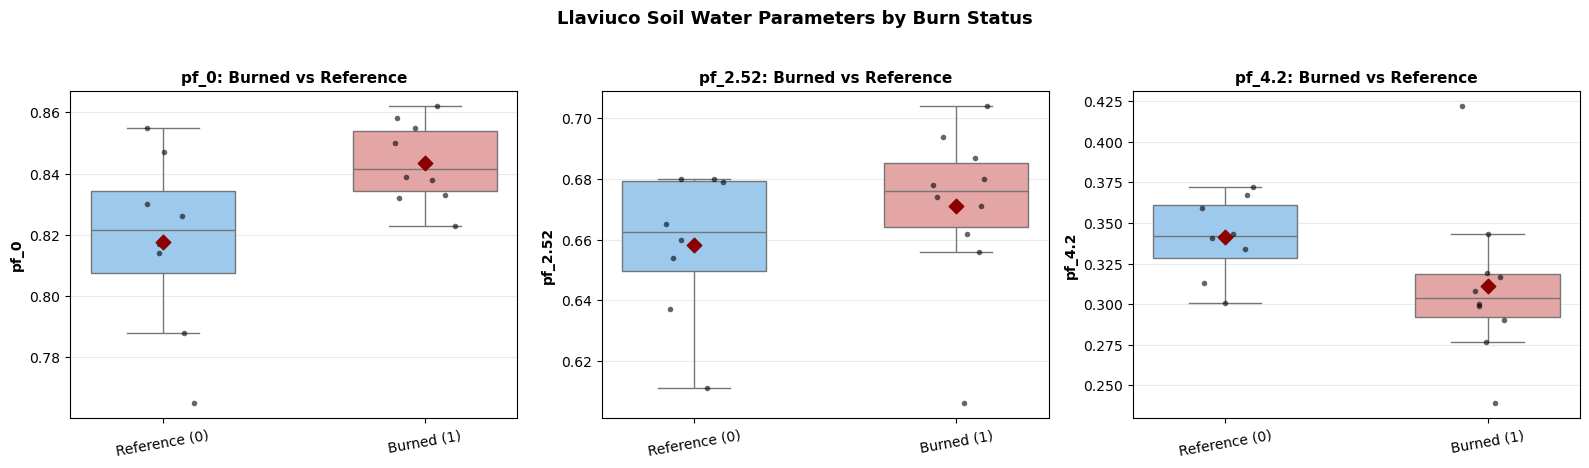

Visualization saved as 'llaviuco_burned_vs_reference_pf_boxplots.png'


In [16]:
# Visualizations: Llaviuco burned (1) vs reference (0) for pf variables
plot_df = llaviuco_merged.copy()
plot_df['Burn_Label'] = plot_df['Burn_Status'].map({0: 'Reference (0)', 1: 'Burned (1)'})

pf_plot_cols = [' pf_0', ' pf_2.52', ' pf_4.2']
pf_plot_titles = ['pf_0', 'pf_2.52', 'pf_4.2']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=False)

for ax, col, title in zip(axes, pf_plot_cols, pf_plot_titles):
    sns.boxplot(
        data=plot_df,
        x='Burn_Label',
        y=col,
        ax=ax,
        width=0.55,
        showfliers=False,
        palette=['#90CAF9', '#EF9A9A']
    )
    sns.stripplot(
        data=plot_df,
        x='Burn_Label',
        y=col,
        ax=ax,
        color='black',
        alpha=0.6,
        jitter=0.12,
        size=4
    )

    # Add mean markers
    means = plot_df.groupby('Burn_Label')[col].mean()
    x_positions = [0, 1]
    for xpos, label in zip(x_positions, ['Reference (0)', 'Burned (1)']):
        if label in means.index:
            ax.scatter(xpos, means[label], color='darkred', s=55, marker='D', zorder=5)

    ax.set_title(f'{title}: Burned vs Reference', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(title, fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.25)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Llaviuco Soil Water Parameters by Burn Status', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('llaviuco_burned_vs_reference_pf_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved as 'llaviuco_burned_vs_reference_pf_boxplots.png'")